In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
print("imported !!!")

imported !!!


In [2]:
data = pd.DataFrame({
    'x': [ 1, 2, 3, 4, 5],
    'y': [ 1, 1, 2, 2, 4]
})

In [3]:
data

,x,y
0,1,1
1,2,1
2,3,2
3,4,2
4,5,4


In [4]:
data['x**2'] = data['x']**2

In [5]:
data['x*y'] = data['x'] * data['y']

In [6]:
data

,x,y,x**2,x*y
0,1,1,1,1
1,2,1,4,2
2,3,2,9,6
3,4,2,16,8
4,5,4,25,20


In [7]:
a0 = -0.1
a1 = 0.7

In [8]:
def y_predict(x, y, x2, xy):
    return a0 + a1*x

In [9]:
data['y_pred'] =  y_predict(data['x'], data['y'], data['x**2'], data['x*y'])
data

,x,y,x**2,x*y,y_pred
0,1,1,1,1,0.6
1,2,1,4,2,1.3
2,3,2,9,6,2.0
3,4,2,16,8,2.7
4,5,4,25,20,3.4


In [10]:
data['err'] = data['y'] - data['y_pred']

In [11]:
sum_err = data['err'].sum()
sum_err

9.992007221626409e-16

In [12]:
data['err**2'] = data['err']**2

In [13]:
data

,x,y,x**2,x*y,y_pred,err,err**2
0,1,1,1,1,0.6,4.000000e-01,1.600000e-01
1,2,1,4,2,1.3,-3.000000e-01,9.000000e-02
2,3,2,9,6,2.0,4.440892e-16,1.972152e-31
3,4,2,16,8,2.7,-7.000000e-01,4.900000e-01
4,5,4,25,20,3.4,6.000000e-01,3.600000e-01


In [14]:
sse = data['err**2'].sum()
sse

1.0999999999999996

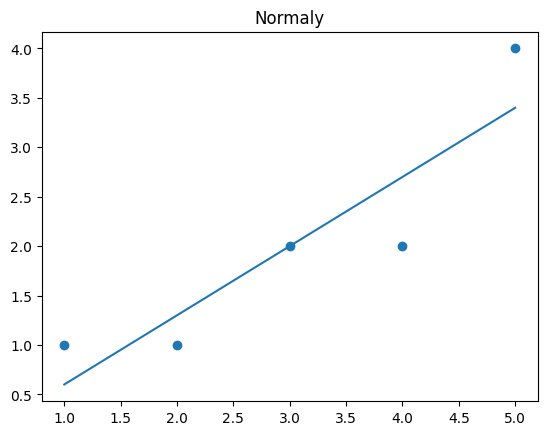

In [15]:
plt.title("Normaly")
plt.scatter(data['x'], data['y'])
plt.plot(data['x'], data['y_pred'])
plt.show()

In [16]:
a_vals = [-0.9, -0.7, -0.5, -0.3, 0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7]

In [17]:
def y_pred(x, a0, a1):
    return a0 + a1*x

In [18]:
data['yp0'] = y_pred(data['x'], a0, a_vals[0])
data["s0"] = data['y'] - data['yp0']
data['s0']

0    2.0
1    2.9
2    4.8
3    5.7
4    8.6
Name: s0, dtype: float64

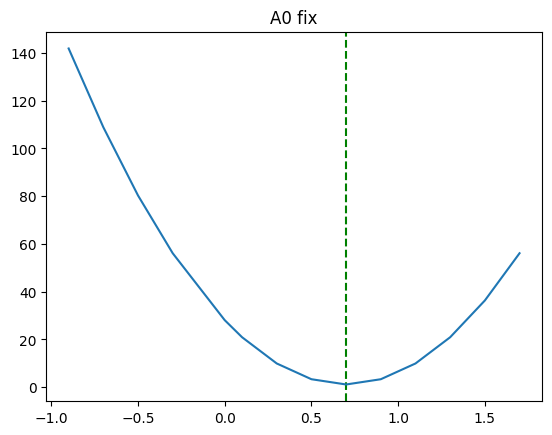

In [25]:
# fix a0
plt.title("A0 fix")
sse_list = []
opt_a1 = a_vals[0]
min_sse = float('inf')
for i in a_vals:
    s = data['y'] - y_pred(data['x'], a0, i)
    s = s*s
    sse = s.sum()
    # print(s.sum())
    sse_list.append(sse)    
    if sse < min_sse:
        min_sse = sse
        opt_a1 = i


plt.axvline(opt_a1, color='green', linestyle='--', label='Optimal a1')
plt.plot(a_vals, sse_list)
plt.show()
        

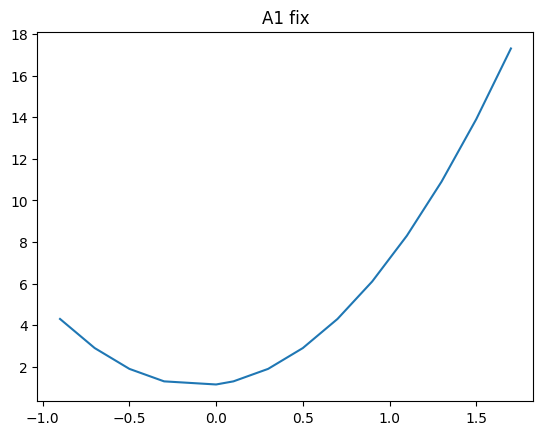

In [20]:
# fix a1
plt.title("A1 fix")
sse_list = []
for i in a_vals:
    s = data['y'] - y_pred(data['x'], i, a1)
    s = s*s
    # print(s.sum())
    sse_list.append(s.sum())    

plt.plot(a_vals, sse_list, )
plt.show()
        

In [21]:
data['xy'] = data['x']*data['y']
data

,x,y,x**2,x*y,y_pred,err,err**2,yp0,s0,xy
0,1,1,1,1,0.6,4.000000e-01,1.600000e-01,-1.0,2.0,1
1,2,1,4,2,1.3,-3.000000e-01,9.000000e-02,-1.9,2.9,2
2,3,2,9,6,2.0,4.440892e-16,1.972152e-31,-2.8,4.8,6
3,4,2,16,8,2.7,-7.000000e-01,4.900000e-01,-3.7,5.7,8
4,5,4,25,20,3.4,6.000000e-01,3.600000e-01,-4.6,8.6,20


In [22]:
a1 = (5*data['xy'].sum() - data['x'].sum()*data['y'].sum()) / (5*data['x**2'].sum() - (data['x'].sum())**2)

In [23]:
a1

0.7

In [24]:
df = pd.DataFrame({
    'x': [4, 6, 10, 12],
    'y': [3, 5.5, 6.5, 9]
})

In [25]:
df

,x,y
0,4,3.0
1,6,5.5
2,10,6.5
3,12,9.0


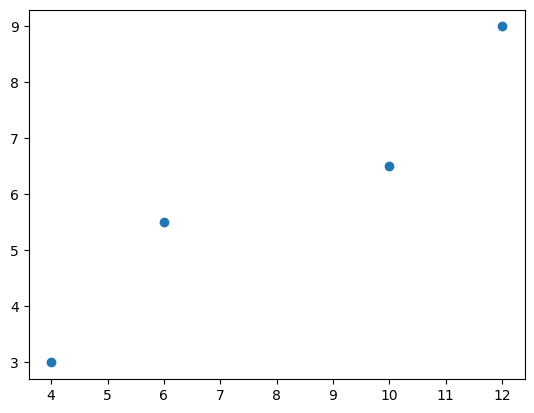

In [26]:
plt.scatter(df['x'], df['y'])
plt.show()

In [27]:
df['xy'] = df['x']*df['y']
df

,x,y,xy
0,4,3.0,12.0
1,6,5.5,33.0
2,10,6.5,65.0
3,12,9.0,108.0


In [28]:
df['x**2'] = df['x']**2
df['y**2'] = df['y']**2
df

,x,y,xy,x**2,y**2
0,4,3.0,12.0,16,9.00
1,6,5.5,33.0,36,30.25
2,10,6.5,65.0,100,42.25
3,12,9.0,108.0,144,81.00


In [29]:
a1_df = (4*df['xy'].sum() - df['x'].sum()*df['y'].sum()) / (4*df['x**2'].sum() - (df['x'].sum())**2)

# 

In [30]:
a1_df

0.65

In [31]:
a0_df = data['y'].mean() - data['x'].mean()*a1_df

In [32]:
a0_df

0.04999999999999982

In [33]:
df['y_pred'] = y_pred(df['x'], a0_df, a1_df)

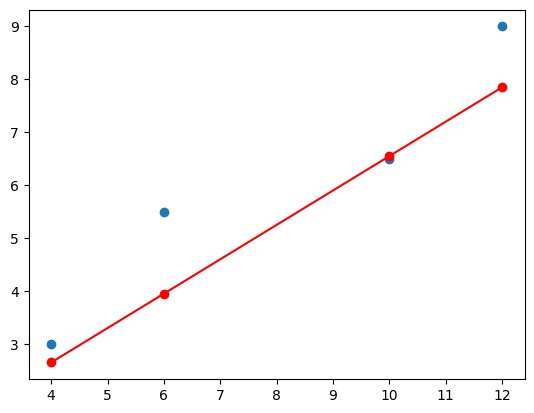

In [34]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['y_pred'], marker='o', color='red')
plt.show()

In [35]:
df['err'] = df['y'] - df['y_pred']
df['err**2'] = df['err']**2


In [36]:
sse = df['err**2'].sum()

In [37]:
df

,x,y,xy,x**2,y**2,y_pred,err,err**2
0,4,3.0,12.0,16,9.00,2.65,0.35,0.1225
1,6,5.5,33.0,36,30.25,3.95,1.55,2.4025
2,10,6.5,65.0,100,42.25,6.55,-0.05,0.0025
3,12,9.0,108.0,144,81.00,7.85,1.15,1.3225


In [38]:
0.65*2

1.3

In [39]:
1/0.65

1.5384615384615383

# height width data

In [40]:
hw_data = pd.read_excel("H and W (ML) Data.xlsx")

In [41]:
hw_data

,Sr. No.,Name,Roll No.,Height (in cm),Weight (in kg)
0,1,Vishal Baghel,1,170.00,70.00
1,2,Gautam Chauhan,4,173.00,85.00
2,3,Mohit Dadwani,5,172.00,53.00
3,4,Etiko Solih,7,180.00,65.00
4,5,Aatreyee,13,175.00,80.00
5,6,Aasima,18,167.64,55.00
6,7,Panchal dhruvi,22,164.00,62.00
7,8,Jay Panchal,23,180.00,70.00
8,9,Kaushal Jayeshbhai Panchal,24,183.00,60.00
9,10,Dev Patel,25,170.00,68.00


In [42]:
xy_hw = hw_data[['Height (in cm)', 'Weight (in kg)']]
xy_hw

,Height (in cm),Weight (in kg)
0,170.00,70.00
1,173.00,85.00
2,172.00,53.00
3,180.00,65.00
4,175.00,80.00
5,167.64,55.00
6,164.00,62.00
7,180.00,70.00
8,183.00,60.00
9,170.00,68.00


In [43]:
xy_hw['x'] = xy_hw['Height (in cm)']
xy_hw['y'] = xy_hw['Weight (in kg)']
xy_hw['xy'] = xy_hw['x']*xy_hw['y']
# a1_hw = (4*df['xy'].sum() - df['x'].sum()*df['y'].sum()) / (4*df['x**2'].sum() - (df['x'].sum())**2)
# a0_hw
# xy_hw['yp0'] = y_pred(xy_hw['x'], a0, a_vals[0])
# xy_hw["s0"] = xy_hw['y'] - xy_hw['yp0']
# xy_hw['s0']

C:\Users\Rohit\AppData\Local\Temp\ipykernel_10004\1532919339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xy_hw['x'] = xy_hw['Height (in cm)']
C:\Users\Rohit\AppData\Local\Temp\ipykernel_10004\1532919339.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xy_hw['y'] = xy_hw['Weight (in kg)']
